In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# data spliting
from sklearn.model_selection import train_test_split


# model training
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# metrices
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve


In [206]:
df = pd.read_csv("data/customer_booking.csv", encoding="ISO-8859-1")

In [207]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [ ]:
df["trip_type_CircleTrip"].value_counts()

### 1. Converting sales_channel, trip_type to integer values for better analysis

In [ ]:
# channel_mapping={
#     "Internet": 0,
#     "Mobile": 1,
#     # "Corporate": 2
# }
# trip_mapping = {
#     "RoundTrip": 0,
#     "OneWay": 1,
#     "CircleTrip": 2
# }
# df["sales_channel"] = df["sales_channel"].map(channel_mapping)
# df["trip_type"] = df["trip_type"].map(trip_mapping)

In [211]:
df.columns

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'flight_day', 'route', 'booking_origin', 'wants_extra_baggage',
       'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration',
       'booking_complete', 'trip_type_OneWay', 'trip_type_RoundTrip',
       'sales_channel_Mobile'],
      dtype='str')

In [210]:
df = pd.get_dummies(df, columns=["trip_type", "sales_channel"], prefix =["trip_type", "sales_channel"], dtype = np.int16, drop_first=True)

### 2. purchase_leads --> lead_bin --> one hot encoded columns

In [212]:
purchase_bins = [0, 14, 30, 60, 120, 190, 265, 365, float("inf")]

df["lead_bin"] = pd.cut(df["purchase_lead"], bins=purchase_bins)

In [213]:
# before model training
df = pd.get_dummies(df, columns = ["lead_bin"], prefix="lead_bin",dtype = np.int16, drop_first=True)

### 3. length_of_stay --> stay_bin --> one hot encoded columns

In [214]:
stay_bin = [0, 3, 7, 14, 30, 60, 150, float("inf")]

df["stay_bin"] = pd.cut(df["length_of_stay"], bins = stay_bin)

In [215]:
# before model training
df = pd.get_dummies(df, columns = ["stay_bin"], prefix="stay_bin",dtype = np.int16, drop_first=True)

### 4. flight_hour --> flight_time_of_day --> one hot encoded columns

In [216]:
def get_time_of_day(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["flight_time_of_day"] = df["flight_hour"].apply(get_time_of_day)

In [ ]:
# time_map = {
#     "Morning": 0,
#     "Afternoon": 1,
#     "Evening": 2,
#     "Night": 3
# }

# df["flight_time_of_day"] = df["flight_time_of_day"].map(time_map)

In [217]:
# before model training
df = pd.get_dummies(df, columns=["flight_time_of_day"], prefix = "flight_time", dtype = np.int16, drop_first=True)

In [224]:
df.columns

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'route', 'booking_origin', 'wants_extra_baggage',
       'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration',
       'booking_complete', 'trip_type_OneWay', 'trip_type_RoundTrip',
       'sales_channel_Mobile', 'lead_bin_(14.0, 30.0]',
       'lead_bin_(30.0, 60.0]', 'lead_bin_(60.0, 120.0]',
       'lead_bin_(120.0, 190.0]', 'lead_bin_(190.0, 265.0]',
       'lead_bin_(265.0, 365.0]', 'lead_bin_(365.0, inf]',
       'stay_bin_(3.0, 7.0]', 'stay_bin_(7.0, 14.0]', 'stay_bin_(14.0, 30.0]',
       'stay_bin_(30.0, 60.0]', 'stay_bin_(60.0, 150.0]',
       'stay_bin_(150.0, inf]', 'flight_time_Evening', 'flight_time_Morning',
       'flight_time_Night', 'is_weekend_flight', 'flight_day_Mon',
       'flight_day_Sat', 'flight_day_Sun', 'flight_day_Thu', 'flight_day_Tue',
       'flight_day_Wed', 'route_frequency', 'origin_booking_frequency'],
      dtype='str')

### 5. flight_day --> is_weekend_flight, 0/1 (F/T)

In [219]:
df["is_weekend_flight"] = df["flight_day"].isin(["Sat", "Sun"]).astype(int)

In [ ]:
# day_map = {
# "Mon": 0,
# "Wed": 1,
# "Tue": 2,
# "Thu": 3,
# "Fri": 4,
# "Sun": 5,
# "Sat": 6

# }
# df["flight_day"] = df["flight_day"].map(day_map)

In [220]:
df = pd.get_dummies(df, columns=["flight_day"], prefix = "flight_day", dtype = np.int16, drop_first=True)

### 6. route ---> after spliting route_booking_rate, before splitting route_frequency

In [222]:
route_freq = df["route"].value_counts()
df["route_frequency"] = df["route"].map(route_freq)

### 7. booking_origin ---> after splitting origin_booking_rate, before splitting origin_booking_frequency

In [223]:
origin_booking_freq = df["booking_origin"].value_counts()
df["origin_booking_frequency"] = df["booking_origin"].map(origin_booking_freq)

### 8. total_extra_request ---> sum of extra baggage, prefered seat, extra 

- request fulfilled completion rate:  
    - if requested 3 services, what is the completion rate,
    - if requested 2 services, what is teh completion rate,
    - if requested 1 services, waht is the completion rate,
    - if requested 0 services, what is the completion rate

In [225]:
df["total_extra_request"] = df["wants_extra_baggage"] + df["wants_preferred_seat"] + df["wants_in_flight_meals"]

### Split the data fro training and testing

In [226]:
df.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,...,is_weekend_flight,flight_day_Mon,flight_day_Sat,flight_day_Sun,flight_day_Thu,flight_day_Tue,flight_day_Wed,route_frequency,origin_booking_frequency,total_extra_request
0,2,262,19,7,AKLDEL,New Zealand,1,0,0,5.52,...,1,0,1,0,0,0,0,20,1074,1
1,1,112,20,3,AKLDEL,New Zealand,0,0,0,5.52,...,1,0,1,0,0,0,0,20,1074,0
2,2,243,22,17,AKLDEL,India,1,1,0,5.52,...,0,0,0,0,0,0,1,20,1270,2
3,1,96,31,4,AKLDEL,New Zealand,0,0,1,5.52,...,1,0,1,0,0,0,0,20,1074,1
4,2,68,22,15,AKLDEL,India,1,0,1,5.52,...,0,0,0,0,0,0,1,20,1270,2


In [227]:
df.columns

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'route', 'booking_origin', 'wants_extra_baggage',
       'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration',
       'booking_complete', 'trip_type_OneWay', 'trip_type_RoundTrip',
       'sales_channel_Mobile', 'lead_bin_(14.0, 30.0]',
       'lead_bin_(30.0, 60.0]', 'lead_bin_(60.0, 120.0]',
       'lead_bin_(120.0, 190.0]', 'lead_bin_(190.0, 265.0]',
       'lead_bin_(265.0, 365.0]', 'lead_bin_(365.0, inf]',
       'stay_bin_(3.0, 7.0]', 'stay_bin_(7.0, 14.0]', 'stay_bin_(14.0, 30.0]',
       'stay_bin_(30.0, 60.0]', 'stay_bin_(60.0, 150.0]',
       'stay_bin_(150.0, inf]', 'flight_time_Evening', 'flight_time_Morning',
       'flight_time_Night', 'is_weekend_flight', 'flight_day_Mon',
       'flight_day_Sat', 'flight_day_Sun', 'flight_day_Thu', 'flight_day_Tue',
       'flight_day_Wed', 'route_frequency', 'origin_booking_frequency',
       'total_extra_request'],
      dtype='str')

In [228]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   num_passengers            50000 non-null  int64  
 1   purchase_lead             50000 non-null  int64  
 2   length_of_stay            50000 non-null  int64  
 3   flight_hour               50000 non-null  int64  
 4   route                     50000 non-null  str    
 5   booking_origin            50000 non-null  str    
 6   wants_extra_baggage       50000 non-null  int64  
 7   wants_preferred_seat      50000 non-null  int64  
 8   wants_in_flight_meals     50000 non-null  int64  
 9   flight_duration           50000 non-null  float64
 10  booking_complete          50000 non-null  int64  
 11  trip_type_OneWay          50000 non-null  int16  
 12  trip_type_RoundTrip       50000 non-null  int16  
 13  sales_channel_Mobile      50000 non-null  int16  
 14  lead_bin_(14.0, 3

In [229]:
X = df.drop(columns=["booking_complete"])
y = df["booking_complete"]

In [230]:
print(X.columns)


Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'route', 'booking_origin', 'wants_extra_baggage',
       'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration',
       'trip_type_OneWay', 'trip_type_RoundTrip', 'sales_channel_Mobile',
       'lead_bin_(14.0, 30.0]', 'lead_bin_(30.0, 60.0]',
       'lead_bin_(60.0, 120.0]', 'lead_bin_(120.0, 190.0]',
       'lead_bin_(190.0, 265.0]', 'lead_bin_(265.0, 365.0]',
       'lead_bin_(365.0, inf]', 'stay_bin_(3.0, 7.0]', 'stay_bin_(7.0, 14.0]',
       'stay_bin_(14.0, 30.0]', 'stay_bin_(30.0, 60.0]',
       'stay_bin_(60.0, 150.0]', 'stay_bin_(150.0, inf]',
       'flight_time_Evening', 'flight_time_Morning', 'flight_time_Night',
       'is_weekend_flight', 'flight_day_Mon', 'flight_day_Sat',
       'flight_day_Sun', 'flight_day_Thu', 'flight_day_Tue', 'flight_day_Wed',
       'route_frequency', 'origin_booking_frequency', 'total_extra_request'],
      dtype='str')


In [231]:
y

0        0
1        0
2        0
3        0
4        0
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Name: booking_complete, Length: 50000, dtype: int64

In [232]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [233]:
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(40000, 39) (10000, 39) (40000,) (10000,)


In [234]:
X_train.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,...,is_weekend_flight,flight_day_Mon,flight_day_Sat,flight_day_Sun,flight_day_Thu,flight_day_Tue,flight_day_Wed,route_frequency,origin_booking_frequency,total_extra_request
39087,1,15,5,13,ICNKCH,Malaysia,0,0,1,6.62,...,1,0,0,1,0,0,0,106,7174,1
30893,1,298,4,9,DMKMEL,Thailand,1,0,0,8.83,...,0,1,0,0,0,0,0,351,2030,1
45278,2,200,6,5,DPSICN,South Korea,1,0,0,6.62,...,0,0,0,0,0,0,1,666,4559,1
16398,1,79,21,11,KCHSYD,Australia,1,0,0,8.58,...,1,0,1,0,0,0,0,68,17872,1
13653,1,105,20,6,ICNMAA,South Korea,1,0,1,6.62,...,1,0,0,1,0,0,0,33,4559,2


#### calculating route_booking_rate, origin_booking_rate

In [235]:
route_rate_map = Y_train.groupby(X_train["route"]).mean()
origin_rate_map = Y_train.groupby(X_train["booking_origin"]).mean()

print(route_rate_map)
print(origin_rate_map)

route
AKLDEL    0.000000
AKLHGH    0.000000
AKLHND    0.000000
AKLICN    0.000000
AKLKIX    0.000000
            ...   
TPEURT    0.000000
TRZWUH    0.000000
TRZXIY    0.000000
TWUWUH    0.500000
TWUXIY    0.333333
Name: booking_complete, Length: 777, dtype: float64
booking_origin
(not set)               0.161765
Afghanistan             0.000000
Algeria                 0.000000
Argentina               0.000000
Australia               0.050216
                          ...   
United Arab Emirates    0.052632
United Kingdom          0.113636
United States           0.192837
Vanuatu                 1.000000
Vietnam                 0.286604
Name: booking_complete, Length: 98, dtype: float64


In [236]:
X_train["route_booking_rate"] = X_train["route"].map(route_rate_map)
X_test["route_booking_rate"] = X_test["route"].map(route_rate_map)

In [246]:
print(X_train["route_booking_rate"].info())
print(X_test["route_booking_rate"].info())

<class 'pandas.Series'>
Index: 40000 entries, 39087 to 15795
Series name: route_booking_rate
Non-Null Count  Dtype  
--------------  -----  
40000 non-null  float64
dtypes: float64(1)
memory usage: 625.0 KB
None
<class 'pandas.Series'>
Index: 10000 entries, 33553 to 5857
Series name: route_booking_rate
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 156.2 KB
None


In [242]:
X_train["origin_booking_rate"] = X_train["booking_origin"].map(origin_rate_map)
X_test["origin_booking_rate"] = X_test["booking_origin"].map(origin_rate_map)

In [247]:
print(X_train["origin_booking_rate"].info())
print(X_test["origin_booking_rate"].info())
# print(X_train["origin_booking_rate"].unique())
# print(X_test["origin_booking_rate"].unique())

<class 'pandas.Series'>
Index: 40000 entries, 39087 to 15795
Series name: origin_booking_rate
Non-Null Count  Dtype  
--------------  -----  
40000 non-null  float64
dtypes: float64(1)
memory usage: 625.0 KB
None
<class 'pandas.Series'>
Index: 10000 entries, 33553 to 5857
Series name: origin_booking_rate
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 156.2 KB
None


#### Covering unseen or nan value in test dataset by mean

In [244]:
overall_rate = Y_train.mean() # fill unseen categories in test with overall train average


In [245]:
X_train["route_booking_rate"] = X_train["route_booking_rate"].fillna(overall_rate, inplace = True)
X_test["route_booking_rate"] = X_test["route_booking_rate"].fillna(overall_rate, inplace = True)

X_train["origin_booking_rate"] = X_train["origin_booking_rate"].fillna(overall_rate, inplace = True)
X_test["origin_booking_rate"] = X_test["origin_booking_rate"].fillna(overall_rate, inplace = True)

C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2482324599.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X_train["route_booking_rate"] = X_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2482324599.py:2: ChainedAssignmentError: A value is being set on a copy o

#### Total extra request booking completion rate --- nont use full

In [95]:
extra_request_map = Y_train.groupby(X_train["total_extra_request"]).mean()
extra_request_map

total_extra_request
0    0.108600
1    0.148628
2    0.162138
3    0.185042
Name: booking_complete, dtype: float64

In [254]:
X_train.columns

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals',
       'flight_duration', 'trip_type_OneWay', 'trip_type_RoundTrip',
       'sales_channel_Mobile', 'lead_bin_(14.0, 30.0]',
       'lead_bin_(30.0, 60.0]', 'lead_bin_(60.0, 120.0]',
       'lead_bin_(120.0, 190.0]', 'lead_bin_(190.0, 265.0]',
       'lead_bin_(265.0, 365.0]', 'lead_bin_(365.0, inf]',
       'stay_bin_(3.0, 7.0]', 'stay_bin_(7.0, 14.0]', 'stay_bin_(14.0, 30.0]',
       'stay_bin_(30.0, 60.0]', 'stay_bin_(60.0, 150.0]',
       'stay_bin_(150.0, inf]', 'flight_time_Evening', 'flight_time_Morning',
       'flight_time_Night', 'is_weekend_flight', 'flight_day_Mon',
       'flight_day_Sat', 'flight_day_Sun', 'flight_day_Thu', 'flight_day_Tue',
       'flight_day_Wed', 'route_frequency', 'origin_booking_frequency',
       'total_extra_request', 'route_booking_rate', 'origin_booking_rate'],
      dtype='str')

In [253]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 40000 entries, 39087 to 15795
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   num_passengers            40000 non-null  int64  
 1   purchase_lead             40000 non-null  int64  
 2   length_of_stay            40000 non-null  int64  
 3   flight_hour               40000 non-null  int64  
 4   wants_extra_baggage       40000 non-null  int64  
 5   wants_preferred_seat      40000 non-null  int64  
 6   wants_in_flight_meals     40000 non-null  int64  
 7   flight_duration           40000 non-null  float64
 8   trip_type_OneWay          40000 non-null  int16  
 9   trip_type_RoundTrip       40000 non-null  int16  
 10  sales_channel_Mobile      40000 non-null  int16  
 11  lead_bin_(14.0, 30.0]     40000 non-null  int16  
 12  lead_bin_(30.0, 60.0]     40000 non-null  int16  
 13  lead_bin_(60.0, 120.0]    40000 non-null  int16  
 14  lead_bin_(120.0, 1

#### Dropping the route and booking_origin columns.

In [252]:
X_train = X_train.drop(columns=["route", "booking_origin"])
X_test = X_test.drop(columns=["route", "booking_origin"])

# Model Training : Random Forest Classifier

In [259]:
classifier = RandomForestClassifier(n_estimators = 300, max_depth = 3, class_weight = "balanced", random_state = 42)

In [260]:
classifier.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

In [261]:
print(f"Score test: {str(classifier.score(X_test, Y_test))}")

Score test: 0.6782


In [263]:
print(classification_report(Y_test, classifier.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.66      0.78      8520
           1       0.29      0.79      0.42      1480

    accuracy                           0.68     10000
   macro avg       0.62      0.72      0.60     10000
weighted avg       0.85      0.68      0.72     10000



## Cross validation

In [289]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [290]:
skf = StratifiedKFold(n_splits = 20, random_state = 1, shuffle = True)

accuracy = []
precision = []
recall = []
f1 = []

prediction_report = {} # storing the prediction report into a dictionary
i = 0 # to track the fold number

In [291]:
type(accuracy_score)

function

In [ ]:
for train_index, test_index in skf.split(X, y):
    # use splited index vakue ti split the data from dataframe for tarining and testing
    x_train = X.iloc[train_index, :]
    x_test = X.iloc[test_index, :]
    y_train = y[train_index]
    y_test = y[test_index]

    # calculate the booking rate for each route and origin in the training set
    route_rate_map = y_train.groupby(x_train["route"]).mean()
    origin_rate_map = y_train.groupby(x_train["booking_origin"]).mean()

    # creating column with booking rate for each route and origin in the training and testing set
    x_train["route_booking_rate"] = x_train["route"].map(route_rate_map)
    x_test["route_booking_rate"] = x_test["route"].map(route_rate_map)
    x_train["origin_booking_rate"] = x_train["booking_origin"].map(origin_rate_map)
    x_test["origin_booking_rate"] = x_test["booking_origin"].map(origin_rate_map)


    # fill unseen vakue with overall booking rate in the training set
    overall_rate = y_train.mean()

    x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
    x_test["route_booking_rate"] = x_test["route_booking_rate"].fillna(overall_rate, inplace = True)

    x_train["origin_booking_rate"] = x_train["origin_booking_rate"].fillna(overall_rate, inplace = True)
    x_test["origin_booking_rate"] = x_test["origin_booking_rate"].fillna(overall_rate, inplace = True)


    # drop the route and booking origin columns from the training and testing set
    x_train = x_train.drop(columns=["route", "booking_origin"])
    x_test = x_test.drop(columns=["route", "booking_origin"])

    

    classifier.fit(x_train, y_train)

    y_pred = classifier.predict(x_test)

    prediction_report[f"fold_{i}"] = {
                                    "accuracy_score ": accuracy_score(y_test, y_pred),
                                    "precision_score ": precision_score(y_test, y_pred),
                                    "recall_score": recall_score(y_test, y_pred),
                                    "f1_score":f1_score(y_test, y_pred)
                                    }
    accuracy.append(accuracy_score(y_test, y_pred))
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred)) 

    print(f"\nPrediction report: {prediction_report}")
    # print(f"\nAverage accuracy score: {sum(accuracy)/len(accuracy)}")
    # print(f"\nAverage precision score: {sum(precision)/len(precision)}")
    # print(f"\nAverage recall score: {sum(recall)/len(recall)}")
    # print(f"\nAverage f1 score: {sum(f1)/len(f1)}")




C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.68, 'precision_score ': 0.28923988153998026, 'recall_score': 0.7855227882037533, 'f1_score': 0.4227994227994228}}

Average accuracy score: 0.68

Average precision score: 0.28923988153998026

Average recall score: 0.7855227882037533

Average f1 score: 0.4227994227994228


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6748, 'precision_score ': 0.28431372549019607, 'recall_score': 0.7774798927613941, 'f1_score': 0.416367552045944}}

Average accuracy score: 0.6774

Average precision score: 0.28677680351508816

Average recall score: 0.7815013404825737

Average f1 score: 0.41958348742268337


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6888, 'precision_score ': 0.2963709677419355, 'recall_score': 0.786096256684492, 'f1_score': 0.43045387994143486}}

Average accuracy score: 0.6812

Average precision score: 0.2899748582573706

Average recall score: 0.7830329792165465

Average f1 score: 0.4232069515956005


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6788, 'precision_score ': 0.28949950932286556, 'recall_score': 0.7887700534759359, 'f1_score': 0.4235463029432879}}

Average accuracy score: 0.6806

Average precision score: 0.28985602102374436

Average recall score: 0.7844672477813939

Average f1 score: 0.4232917894325224


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6732, 'precision_score ': 0.2880382775119617, 'recall_score': 0.8048128342245989, 'f1_score': 0.42424242424242425}}

Average accuracy score: 0.67912

Average precision score: 0.2894924723213878

Average recall score: 0.7885363650700349

Average f1 score: 0.4234819163945027


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6812, 'precision_score ': 0.29244357212953875, 'recall_score': 0.7967914438502673, 'f1_score': 0.4278535534816942}}

Average accuracy score: 0.6794666666666668

Average precision score: 0.28998432228941295

Average recall score: 0.789912211533407

Average f1 score: 0.42421052257570135


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.674, 'precision_score ': 0.28736740597878496, 'recall_score': 0.7967914438502673, 'f1_score': 0.4223954642097803}}

Average accuracy score: 0.6786857142857142

Average precision score: 0.2896104771021804

Average recall score: 0.7908949590072442

Average f1 score: 0.4239512285234269


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6692, 'precision_score ': 0.28200192492781523, 'recall_score': 0.7834224598930482, 'f1_score': 0.41472045293701343}}

Average accuracy score: 0.6775

Average precision score: 0.28865940808038476

Average recall score: 0.7899608966179696

Average f1 score: 0.4227973815751252


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6808, 'precision_score ': 0.2925636007827789, 'recall_score': 0.7994652406417112, 'f1_score': 0.4283667621776504}}

Average accuracy score: 0.6778666666666666

Average precision score: 0.2890932072695397

Average recall score: 0.7910169348428298

Average f1 score: 0.42341620164207244


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6696, 'precision_score ': 0.28476190476190477, 'recall_score': 0.7994652406417112, 'f1_score': 0.4199438202247191}}

Average accuracy score: 0.6770400000000001

Average precision score: 0.28866007701877616

Average recall score: 0.7918617654227179

Average f1 score: 0.4230689635003372


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6836, 'precision_score ': 0.2985507246376812, 'recall_score': 0.8262032085561497, 'f1_score': 0.43860894251242016}}

Average accuracy score: 0.6776363636363636

Average precision score: 0.289559226802313

Average recall score: 0.7949837147984845

Average f1 score: 0.4244816888650719


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6944, 'precision_score ': 0.29771784232365145, 'recall_score': 0.767379679144385, 'f1_score': 0.4289985052316891}}

Average accuracy score: 0.6790333333333334

Average precision score: 0.2902391114290912

Average recall score: 0.7926833784939761

Average f1 score: 0.4248580902289567


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6664, 'precision_score ': 0.2796934865900383, 'recall_score': 0.7807486631016043, 'f1_score': 0.4118476727785614}}

Average accuracy score: 0.6780615384615385

Average precision score: 0.2894279095183948

Average recall score: 0.7917653234637937

Average f1 score: 0.4238572888866186


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6872, 'precision_score ': 0.29721669980119286, 'recall_score': 0.7994652406417112, 'f1_score': 0.43333333333333335}}

Average accuracy score: 0.6787142857142857

Average precision score: 0.2899842516814518

Average recall score: 0.7923153175479306

Average f1 score: 0.42453414920424104


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6736, 'precision_score ': 0.2811881188118812, 'recall_score': 0.7593582887700535, 'f1_score': 0.41040462427745666}}

Average accuracy score: 0.6783733333333333

Average precision score: 0.28939784282348047

Average recall score: 0.7901181822960722

Average f1 score: 0.4235921808757888


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6676, 'precision_score ': 0.2809204218600192, 'recall_score': 0.7834224598930482, 'f1_score': 0.4135497529992943}}

Average accuracy score: 0.6777

Average precision score: 0.2888680040132641

Average recall score: 0.7896996996458832

Average f1 score: 0.4229645291335079


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6652, 'precision_score ': 0.2813975448536355, 'recall_score': 0.7967914438502673, 'f1_score': 0.41591067690160505}}

Average accuracy score: 0.6769647058823529

Average precision score: 0.2884285652391683

Average recall score: 0.7901168610696705

Average f1 score: 0.42254959664927827


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6692, 'precision_score ': 0.28200192492781523, 'recall_score': 0.7834224598930482, 'f1_score': 0.41472045293701343}}

Average accuracy score: 0.6765333333333333

Average precision score: 0.2880715296663154

Average recall score: 0.7897449498931916

Average f1 score: 0.4221146442208192


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.684, 'precision_score ': 0.2952755905511811, 'recall_score': 0.8021390374331551, 'f1_score': 0.4316546762589928}}

Average accuracy score: 0.6769263157894736

Average precision score: 0.2884506907655188

Average recall score: 0.7903972702900317

Average f1 score: 0.42261675117019665


C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["route_booking_rate"] = x_train["route_booking_rate"].fillna(overall_rate, inplace = True)
C:\Users\monom\AppData\Local\Temp\ipykernel_24736\2992612304.py:23: ChainedAssignmentError: A value is being set on a copy


Prediction report: {'fold_0': {'accuracy_score ': 0.6752, 'precision_score ': 0.28654970760233917, 'recall_score': 0.786096256684492, 'f1_score': 0.42}}

Average accuracy score: 0.67684

Average precision score: 0.2883556416073598

Average recall score: 0.7901822196097548

Average f1 score: 0.42248591361168686


In [293]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(classifier, X_train, Y_train, cv=cv, scoring="f1")
print(f"CV F1 scores: {scores}")
print(f"Mean F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

CV F1 scores: [0.42752821 0.43673012 0.4351228  0.42516556 0.42462368]
Mean F1: 0.430 (+/- 0.005)


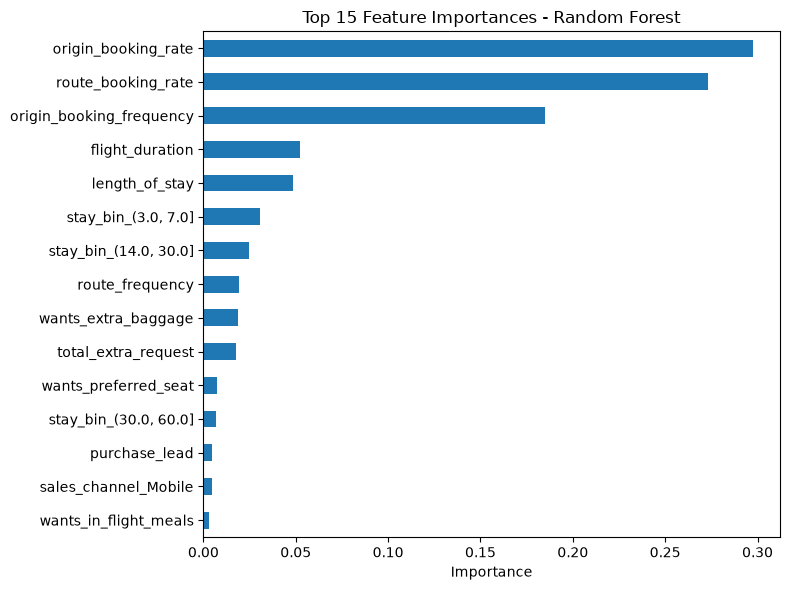

In [294]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(classifier.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

importances.plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [295]:
x_train = X_train[["origin_booking_rate", "route_booking_rate", "origin_booking_frequency"]].copy()
x_test = X_test[["origin_booking_rate", "route_booking_rate", "origin_booking_frequency"]].copy()

In [297]:
classifier.fit(x_train, y_train)

ValueError: Found input variables with inconsistent numbers of samples: [40000, 47500]

# Other models

In [264]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB().fit(X_train, Y_train)
print(classification_report(Y_test, mnb.predict(X_test)))

              precision    recall  f1-score   support

           0       0.87      0.62      0.72      8520
           1       0.18      0.49      0.26      1480

    accuracy                           0.60     10000
   macro avg       0.53      0.55      0.49     10000
weighted avg       0.77      0.60      0.66     10000



In [265]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter = 5000)
lr.fit(X_train, Y_train)
print(classification_report(Y_test, lr.predict(X_test)))   

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8520
           1       0.52      0.10      0.17      1480

    accuracy                           0.85     10000
   macro avg       0.69      0.54      0.55     10000
weighted avg       0.81      0.85      0.81     10000



c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [266]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(X_train, Y_train)
print(classification_report(Y_test, sgd.predict(X_test)))  

              precision    recall  f1-score   support

           0       0.85      0.94      0.90      8520
           1       0.19      0.08      0.11      1480

    accuracy                           0.82     10000
   macro avg       0.52      0.51      0.50     10000
weighted avg       0.76      0.82      0.78     10000



In [267]:
from sklearn.neighbors import KNeighborsClassifier

# instantiate & fit
knn = KNeighborsClassifier(algorithm = 'brute', n_jobs=-1)
knn.fit(X_train, Y_train)
# print("score on test: " + str(knn.score(X_test, Y_test)))
print(classification_report(Y_test, knn.predict(X_test))) 

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      8520
           1       0.36      0.17      0.23      1480

    accuracy                           0.83     10000
   macro avg       0.61      0.56      0.57     10000
weighted avg       0.79      0.83      0.81     10000



In [268]:
from sklearn.svm import LinearSVC

# instantiate & fit
svm=LinearSVC(C=0.0001)
svm.fit(X_train, Y_train)
# print("score on test: " + str(svm.score(x_test, y_test)))
# 1
print(classification_report(Y_test, svm.predict(X_test))) # Table.append(['SVM', svm.score(x_test, y_test)])

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      8520
           1       0.00      0.00      0.00      1480

    accuracy                           0.85     10000
   macro avg       0.43      0.50      0.46     10000
weighted avg       0.73      0.85      0.78     10000



c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [269]:
from sklearn.tree import DecisionTreeClassifier

# instantiate & fit
clf = DecisionTreeClassifier(min_samples_split=10,max_depth=3)
clf.fit(X_train, Y_train)
print(classification_report(Y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      8520
           1       0.00      0.00      0.00      1480

    accuracy                           0.85     10000
   macro avg       0.43      0.50      0.46     10000
weighted avg       0.73      0.85      0.78     10000



c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


# Model Training: XGBoostClassifier

In [272]:
x_train = X_train.copy()
x_test = X_test.copy()

In [273]:
import re
x_train.columns = [re.sub(r'[\[\]<]', '_', col) for col in x_train.columns]
x_test.columns = [re.sub(r'[\[\]<]', '_', col) for col in x_test.columns]

In [274]:
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
bst.fit(x_train, Y_train)

print(classification_report(Y_test, bst.predict(x_test)))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      8520
           1       0.00      0.00      0.00      1480

    accuracy                           0.85     10000
   macro avg       0.43      0.50      0.46     10000
weighted avg       0.73      0.85      0.78     10000



c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\monom\Documents\British Airways Data Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
